# Player Performance Predictor — Exploration, Data Audit, and Model Development

This notebook reconstructs the work that came **before** the final `train_model.py` script.

The notebook follows the actual reasoning path:

1. Load and inspect the raw competition files.
2. Understand the target and data quality.
3. Discover how train and test were split.
4. Identify the exact zero-minute rule.
5. Find the strongest features and establish honest validation.
6. Test simple baselines.
7. Develop the Ridge-plus-residual strategy.
8. Compare model families and regularization settings.
9. Derive the final ensemble used by `train_model.py`.

The goal was to beat the displayed leaderboard score of **0.04335 MSE** using model-generated predictions.

## Important note about `solution.csv`

`data/solution.csv` contains the test labels and Public/Private markers. It is loaded only in the final audit section of this notebook.

- It must not be used as a training dataset.
- The exploratory and validation work uses `train.csv` only.
- `train_model.py` does not read `solution.csv`.
- Looking at solution-based scores while choosing an ensemble is test-set leakage. The notebook shows those audits transparently because they were part of this local exercise.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

RANDOM_STATE = 42
TARGET = "player_rating"

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
print(f"Project root: {ROOT}")
print(f"Data folder:  {DATA_DIR}")

Project root: /home/seif/dev/MIA_Training/Task3
Data folder:  /home/seif/dev/MIA_Training/Task3/data


## 1. Load the raw data

At this stage we do not assume anything about the target, split strategy, missing values, or useful features.

In [2]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
solution_path = DATA_DIR / "solution.csv"

file_inventory = pd.DataFrame(
    [
        {
            "file": path.name,
            "exists": path.exists(),
            "size_mb": path.stat().st_size / (1024 ** 2) if path.exists() else np.nan,
        }
        for path in [train_path, test_path, solution_path]
    ]
)
display(file_inventory)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
display(train.head())
display(test.head())

,file,exists,size_mb
0,train.csv,True,13.554416
1,test.csv,True,3.381597
2,solution.csv,True,0.280483


Train shape: (43584, 75)
Test shape:  (11016, 74)


,Id,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
0,M00001_P00053,P00053,Pedro Gavi,36,Spanish,Spain,1,Goalkeeper,191,80,Left,Fenerbahce,2084465,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0.600000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0.000000,0.000000,0.000000,0,0,66.800000,0.000000,0.000000,9.800000,50.800000,0.000000,38.600000,28.600000,31.400000,65.400000,0,0,67,0
1,M00001_P00054,P00054,Gavi Morata,27,Spanish,Spain,2,Goalkeeper,190,75,Left,Borussia Dortmund,1484206,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0.650000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0.000000,0.000000,0.000000,0,0,56.900000,0.000000,1.300000,9.800000,55.600000,0.000000,35.700000,29.800000,46.200000,47.800000,0,0,392,0
2,M00001_P00056,P00056,Pedro Torres,24,Spanish,Spain,4,Defender,176,78,Left,Legia Warsaw,15191371,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,71,0,0,0,0,0.000000,0.000000,1,36,47,0.770000,0,0,1,0,3,3,4,0,2,0,3,10,0,1,0,0,0,0,0.000000,0,0,0,0,8.600000,1.200000,32.800000,18,10,96.400000,6.400000,63.200000,29.300000,70.500000,6.400000,52.700000,31.300000,68.300000,59.200000,0,0,324,0
3,M00001_P00058,P00058,Rodri Laporte,27,Spanish,Spain,6,Defender,188,80,Right,Legia Warsaw,12330574,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,0,0,0.000000,0.010000,0,44,59,0.750000,1,0,1,0,3,3,1,2,1,0,4,9,1,1,0,0,0,0,0.000000,0,0,0,0,7.900000,0.700000,32.400000,28,17,83.700000,6.700000,65.300000,43.200000,85.600000,6.400000,48.700000,15.300000,61.800000,55.100000,0,1,264,0
4,M00001_P00060,P00060,Ferran Pau,35,Spanish,Spain,8,Defender,179,72,Right,Sporting CP,2223129,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0.890000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000,0,0,0,0,0.000000,0.000000,0.000000,0,0,78.900000,0.000000,2.200000,25.400000,37.500000,0.000000,47.300000,34.300000,45.300000,44.300000,0,0,167,0


,Id,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards
0,M00001_P00055,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.000000,0.000000,0,15,26,0.590000,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.830000,0,1,0,0,7.800000,0.700000,26.500000,13,23,81.900000,50.900000,3.300000,48.200000,1.100000,44.200000,55.900000,42.000000,51.800000,0,0,242,0
1,M00001_P00057,P00057,Gavi Asensio,22,Spanish,Spain,5,Defender,187,76,Right,Grasshoppers,1169641,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0.830000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0.000000,0.000000,0.000000,0,0,83.700000,0.000000,24.300000,45.400000,0.000000,48.500000,27.000000,54.100000,38.900000,0,0,213,0
2,M00001_P00059,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.000000,0.000000,1,33,44,0.760000,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.000000,0,0,0,0,7.500000,0.700000,30.500000,23,18,73.600000,55.400000,33.000000,75.600000,6.200000,44.100000,33.500000,60.000000,56.600000,0,0,440,0
3,M00001_P00064,P00064,Aymeric Yamal,27,Spanish,Spain,12,Defender,181,80,Left,Feyenoord,4476815,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,0,0,0,0,0,0.000000,0.000000,0,0,0,0.820000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0,0,0,0,0.000000,0.000000,0.000000,0,0,78.700000,7.600000,25.100000,50.600000,0.000000,55.100000,40.200000,52.100000,51.300000,0,0,261,0
4,M00001_P00066,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.080000,0.070000,2,72,85,0.850000,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.000000,0,0,0,0,8.800000,1.300000,33.700000,30,19,88.800000,82.900000,79.800000,78.600000,15.300000,99.000000,99.000000,83.400000,54.800000,1,1,245,0


### Initial finding

| Dataset | Rows | Columns |
|---|---:|---:|
| Train | 43,584 | 75 |
| Test | 11,016 | 74 |

The only training-only column should be the target, `player_rating`.

In [3]:
train_only_columns = sorted(set(train.columns) - set(test.columns))
test_only_columns = sorted(set(test.columns) - set(train.columns))

print("Train-only columns:", train_only_columns)
print("Test-only columns: ", test_only_columns)

assert train_only_columns == [TARGET]
assert test_only_columns == []
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
print("Train/test feature schemas are aligned.")

Train-only columns: ['player_rating']
Test-only columns:  []
Train/test feature schemas are aligned.


## 2. Full schema and quality audit

This cell creates a full column catalog rather than inspecting only a few selected fields. It shows the dtype, missing values, unique counts, and example values for every training column.

In [4]:
schema_rows = []
for column in train.columns:
    schema_rows.append(
        {
            "column": column,
            "dtype": str(train[column].dtype),
            "train_missing": int(train[column].isna().sum()),
            "test_missing": int(test[column].isna().sum()) if column in test else np.nan,
            "train_unique": int(train[column].nunique(dropna=False)),
            "test_unique": int(test[column].nunique(dropna=False)) if column in test else np.nan,
            "example": train[column].iloc[0],
        }
    )

schema = pd.DataFrame(schema_rows)
display(schema)

quality_summary = pd.Series(
    {
        "train_missing_cells": int(train.isna().sum().sum()),
        "test_missing_cells": int(test.isna().sum().sum()),
        "duplicate_train_ids": int(train["Id"].duplicated().sum()),
        "duplicate_test_ids": int(test["Id"].duplicated().sum()),
        "duplicate_train_rows": int(train.duplicated().sum()),
        "duplicate_test_rows": int(test.duplicated().sum()),
        "train_memory_mb": train.memory_usage(deep=True).sum() / (1024 ** 2),
        "test_memory_mb": test.memory_usage(deep=True).sum() / (1024 ** 2),
    },
    name="value",
)
display(quality_summary.to_frame())

,column,dtype,train_missing,test_missing,train_unique,test_unique,example
0,Id,str,0,0.000000,43584,"11,016.000000",M00001_P00053
1,player_id,str,0,0.000000,998,250.000000,P00053
2,player_name,str,0,0.000000,995,250.000000,Pedro Gavi
3,age,int64,0,0.000000,23,20.000000,36
4,nationality,str,0,0.000000,48,48.000000,Spanish
5,team,str,0,0.000000,48,48.000000,Spain
6,jersey_number,int64,0,0.000000,26,26.000000,1
7,position,str,0,0.000000,4,4.000000,Goalkeeper
8,height_cm,int64,0,0.000000,36,34.000000,191
9,weight_kg,int64,0,0.000000,21,20.000000,80


,value
train_missing_cells,0.000000
test_missing_cells,0.000000
duplicate_train_ids,0.000000
duplicate_test_ids,0.000000
duplicate_train_rows,0.000000
duplicate_test_rows,0.000000
train_memory_mb,55.950828
test_memory_mb,14.054329


### Quality findings

- No missing values were found in train or test.
- `Id` is unique in both datasets.
- No preprocessing imputation step is required.
- The train and test features have the same order and schema.

## 3. Target analysis

,value
count,"43,584.000000"
mean,3.622476
std,3.164200
min,0.000000
25%,0.000000
50%,5.500000
75%,6.400000
max,9.400000
unique_values,57.000000
zero_rate,0.425018


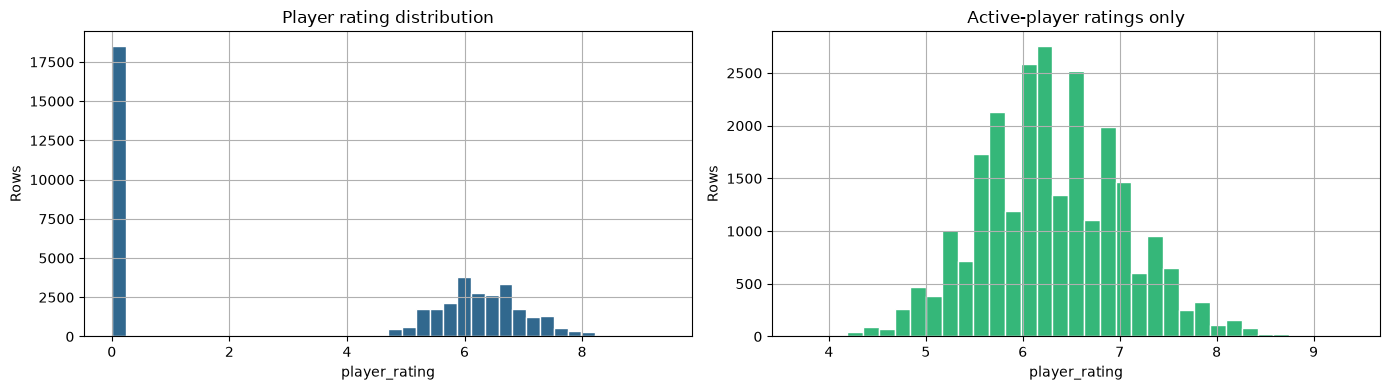

,rows
player_rating,
0.000000,18524
3.700000,4
3.800000,2
3.900000,6
4.000000,7
4.100000,5
4.200000,20
4.300000,24
4.400000,36


In [5]:
target_summary = train[TARGET].describe().to_frame("value")
target_summary.loc["unique_values"] = train[TARGET].nunique()
target_summary.loc["zero_rate"] = train[TARGET].eq(0).mean()
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train[TARGET].hist(bins=40, ax=axes[0], color="#31688e", edgecolor="white")
axes[0].set_title("Player rating distribution")
axes[0].set_xlabel("player_rating")
axes[0].set_ylabel("Rows")

train.loc[train[TARGET].gt(0), TARGET].hist(
    bins=35, ax=axes[1], color="#35b779", edgecolor="white"
)
axes[1].set_title("Active-player ratings only")
axes[1].set_xlabel("player_rating")
axes[1].set_ylabel("Rows")
plt.tight_layout()
plt.show()

display(train[TARGET].value_counts().sort_index().head(20).to_frame("rows"))

### Target findings

```text
Mean:          3.6225
Standard dev:  3.1642
Minimum:       0.0
Median:        5.5
Maximum:       9.4
Unique values: 57
Zero rate:     42.50%
```

The large spike at zero needs investigation before fitting a regression model.

## 4. Discover how train and test were split

The player and match overlap determines whether random row validation is trustworthy.

In [6]:
train_players = set(train["player_id"])
test_players = set(test["player_id"])
train_matches = set(train["match_id"])
test_matches = set(test["match_id"])

split_audit = pd.Series(
    {
        "train_unique_players": len(train_players),
        "test_unique_players": len(test_players),
        "overlapping_players": len(train_players & test_players),
        "train_unique_matches": len(train_matches),
        "test_unique_matches": len(test_matches),
        "overlapping_matches": len(train_matches & test_matches),
        "test_players_unseen_in_train": len(test_players - train_players),
        "test_matches_unseen_in_train": len(test_matches - train_matches),
    },
    name="count",
)
display(split_audit.to_frame())

assert len(train_players & test_players) == 0
assert test_matches.issubset(train_matches)

,count
train_unique_players,998
test_unique_players,250
overlapping_players,0
train_unique_matches,1050
test_unique_matches,1050
overlapping_matches,1050
test_players_unseen_in_train,250
test_matches_unseen_in_train,0


### Critical split finding

```text
Training players: 998
Test players:     250
Player overlap:     0

Test matches:     1,050
Matches in train: 1,050
```

The competition holds out complete players, not random rows. Random row validation could put the same player in training and validation and would not mimic the test set.

Decision: use player-group validation with `player_id` as the group.

## 5. Explain the zero ratings

In [7]:
zero_minute_table = pd.crosstab(
    train["minutes_played"].eq(0),
    train[TARGET].eq(0),
    rownames=["minutes_played == 0"],
    colnames=["player_rating == 0"],
    margins=True,
)
display(zero_minute_table)

zero_minutes_are_zero = train.loc[
    train["minutes_played"].eq(0), TARGET
].eq(0).all()
active_minutes_are_nonzero = train.loc[
    train["minutes_played"].gt(0), TARGET
].gt(0).all()

print("All zero-minute ratings are zero:", zero_minutes_are_zero)
print("All active-player ratings are nonzero:", active_minutes_are_nonzero)

assert zero_minutes_are_zero
assert active_minutes_are_nonzero

player_rating == 0,False,True,All
minutes_played == 0,,,
False,25060,0,25060
True,0,18524,18524
All,25060,18524,43584


All zero-minute ratings are zero: True
All active-player ratings are nonzero: True


### Zero-minute modelling decision

The relationship is exact:

```text
minutes_played == 0 -> player_rating == 0
minutes_played > 0  -> player_rating > 0
```

Therefore all regression models should be trained only on active rows. Predictions for zero-minute test rows should be set directly to `0.0`.

## 6. Numeric correlations and strongest signals

,correlation
performance_score,0.996661
top_speed_kmh,0.979691
distance_covered_km,0.837534
minutes_played,0.837339
sprint_distance_km,0.821266
accelerations,0.799028
decelerations,0.794962
total_passes,0.745521
successful_passes,0.726532
possession_impact,0.623876


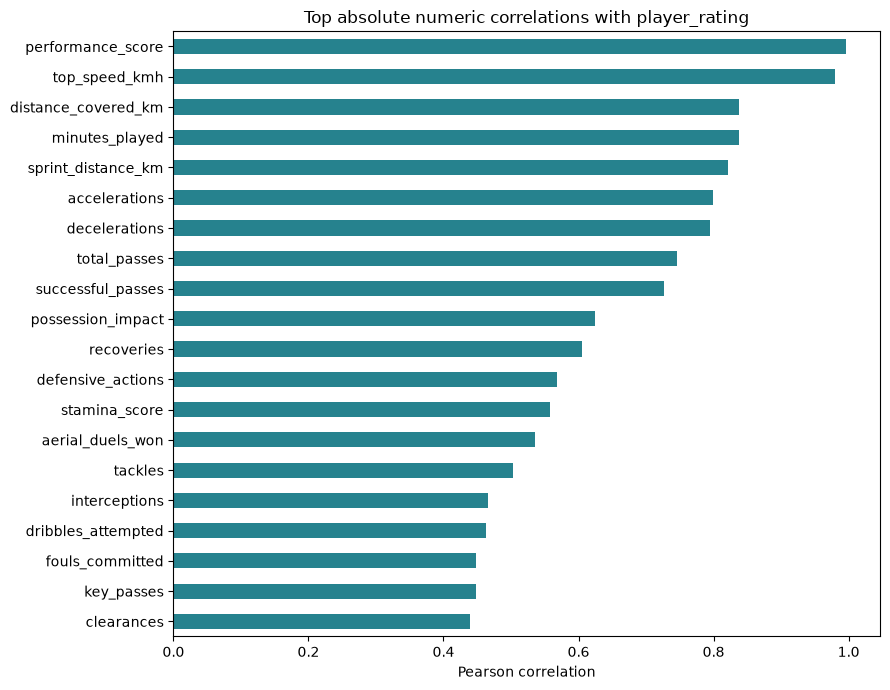

In [8]:
numeric_train = train.select_dtypes(include=np.number)
target_correlations = (
    numeric_train.corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

display(target_correlations.head(30).to_frame("correlation"))

top_correlations = target_correlations.head(20).sort_values()
plt.figure(figsize=(9, 7))
top_correlations.plot(kind="barh", color="#26828e")
plt.title("Top absolute numeric correlations with player_rating")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

### Correlation finding

`performance_score` has approximately `0.996661` correlation with the target. Other strong signals include top speed, minutes, distance, sprint distance, passing volume, possession impact, recoveries, and defensive actions.

This suggests using `performance_score` and the other computed contribution scores as a simple base, then modelling only the remaining error.

## 7. Categorical coverage

We check whether test categories are known during training. Unseen player IDs are expected, while team, venue, position, and match context may still overlap.

In [9]:
categorical_columns = [
    column for column in test.columns if not is_numeric_dtype(test[column])
]

categorical_audit = []
for column in categorical_columns:
    train_values = set(train[column].astype(str))
    test_values = set(test[column].astype(str))
    categorical_audit.append(
        {
            "column": column,
            "train_unique": len(train_values),
            "test_unique": len(test_values),
            "unseen_test_values": len(test_values - train_values),
            "overlap_values": len(test_values & train_values),
        }
    )

categorical_audit = pd.DataFrame(categorical_audit)
display(categorical_audit)

,column,train_unique,test_unique,unseen_test_values,overlap_values
0,Id,43584,11016,11016,0
1,player_id,998,250,250,0
2,player_name,995,250,250,0
3,nationality,48,48,0,48
4,team,48,48,0,48
5,position,4,4,0,4
6,preferred_foot,2,2,0,2
7,club_name,122,103,0,103
8,match_id,1050,1050,0,1050
9,match_date,51,51,0,51


### Categorical decision

- `Id`, `player_id`, and `player_name` are unique or unseen in test and should not be memorized.
- Position, nationality, team, preferred foot, club, match context, stage, and result can be used by categorical models.
- CatBoost is a natural candidate because it handles mixed numeric/categorical inputs directly.

## 8. Numeric train/test distribution comparison

This is an unsupervised shift check. It compares standardized mean differences without using test labels.

In [10]:
numeric_features = [
    column
    for column in train.select_dtypes(include=np.number).columns
    if column != TARGET
]

shift_rows = []
for column in numeric_features:
    train_mean = train[column].mean()
    test_mean = test[column].mean()
    train_std = train[column].std()
    standardized_difference = (
        (test_mean - train_mean) / train_std if train_std > 0 else 0.0
    )
    shift_rows.append(
        {
            "feature": column,
            "train_mean": train_mean,
            "test_mean": test_mean,
            "train_std": train_std,
            "standardized_mean_difference": standardized_difference,
        }
    )

numeric_shift = pd.DataFrame(shift_rows)
numeric_shift["absolute_shift"] = numeric_shift[
    "standardized_mean_difference"
].abs()
display(numeric_shift.sort_values("absolute_shift", ascending=False).head(25))

,feature,train_mean,test_mean,train_std,standardized_mean_difference,absolute_shift
0,age,26.414648,25.828976,4.036415,-0.145097,0.145097
53,consistency_score,64.214021,61.916095,20.036176,-0.114689,0.114689
4,market_value_eur,"20,623,891.820691","17,950,196.554194","27,525,836.474368",-0.097134,0.097134
51,pressure_resistance,60.712973,58.757199,20.354651,-0.096085,0.096085
49,defensive_contribution,53.100613,51.282099,24.053829,-0.075602,0.075602
3,weight_kg,75.814244,75.519880,3.910184,-0.075281,0.075281
48,offensive_contribution,45.007897,43.564279,25.122270,-0.057464,0.057464
2,height_cm,181.582760,181.937545,6.332509,0.056026,0.056026
52,creativity_score,46.382517,45.159577,22.706165,-0.053859,0.053859
41,distance_covered_km,3.967676,4.110557,4.017557,0.035564,0.035564


## 9. Build validation that matches unseen test players

In [11]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_index, valid_index = next(
    group_splitter.split(train, groups=train["player_id"])
)

development_train = train.iloc[train_index].copy()
development_valid = train.iloc[valid_index].copy()

train_fold_players = set(development_train["player_id"])
valid_fold_players = set(development_valid["player_id"])

print("Development train rows:", len(development_train))
print("Validation rows:       ", len(development_valid))
print("Player overlap:        ", len(train_fold_players & valid_fold_players))

assert train_fold_players.isdisjoint(valid_fold_players)

five_fold_splitter = GroupKFold(n_splits=5)
for fold, (fold_train_index, fold_valid_index) in enumerate(
    five_fold_splitter.split(train, groups=train["player_id"]),
    start=1,
):
    fold_train_players = set(train.iloc[fold_train_index]["player_id"])
    fold_valid_players = set(train.iloc[fold_valid_index]["player_id"])
    assert fold_train_players.isdisjoint(fold_valid_players)
    print(
        f"Fold {fold}: train rows={len(fold_train_index):,}, "
        f"valid rows={len(fold_valid_index):,}, player overlap=0"
    )

Development train rows: 34940
Validation rows:        8644
Player overlap:         0
Fold 1: train rows=34,854, valid rows=8,730, player overlap=0
Fold 2: train rows=34,854, valid rows=8,730, player overlap=0
Fold 3: train rows=34,854, valid rows=8,730, player overlap=0
Fold 4: train rows=34,887, valid rows=8,697, player overlap=0
Fold 5: train rows=34,887, valid rows=8,697, player overlap=0


## 10. Initial baselines

Start with the strongest single feature before adding model complexity. The helper below enforces the zero-minute rule for every experiment.

In [12]:
def score_active_model(model, feature_columns, fit_frame, score_frame):
    fit_active = fit_frame["minutes_played"].gt(0)
    score_active = score_frame["minutes_played"].gt(0).to_numpy()

    model.fit(
        fit_frame.loc[fit_active, feature_columns],
        fit_frame.loc[fit_active, TARGET],
    )

    predictions = np.zeros(len(score_frame), dtype=float)
    predictions[score_active] = model.predict(
        score_frame.loc[score_active, feature_columns]
    )
    predictions = np.clip(predictions, 0.0, 10.0)
    return mean_squared_error(score_frame[TARGET], predictions), predictions


validation_active = development_valid["minutes_played"].gt(0).to_numpy()
simple_predictions = np.where(
    validation_active,
    development_valid["performance_score"].to_numpy() / 10.0,
    0.0,
)
print(
    "performance_score / 10 MSE:",
    mean_squared_error(development_valid[TARGET], simple_predictions),
)

for degree in [1, 2, 3, 5]:
    polynomial_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    mse, predictions = score_active_model(
        polynomial_model,
        ["performance_score"],
        development_train,
        development_valid,
    )
    rounded_mse = mean_squared_error(
        development_valid[TARGET], np.round(predictions, 1)
    )
    print(f"Polynomial degree {degree}: raw={mse:.6f}, rounded={rounded_mse:.6f}")

performance_score / 10 MSE: 0.052220777417862095
Polynomial degree 1: raw=0.044602, rounded=0.045157
Polynomial degree 2: raw=0.044573, rounded=0.045074
Polynomial degree 3: raw=0.044577, rounded=0.045126
Polynomial degree 5: raw=0.044590, rounded=0.045161


### Recorded baseline results

| Model | Raw MSE | Rounded MSE |
|---|---:|---:|
| `performance_score / 10` | 0.052221 | 0.052630 |
| Polynomial degree 1 | 0.044602 | 0.045157 |
| Polynomial degree 2 | 0.044573 | 0.045074 |
| Polynomial degree 3 | 0.044577 | 0.045126 |
| Polynomial degree 5 | 0.044590 | 0.045161 |

The main conclusions were:

- Higher polynomial degrees did not help.
- Rounding predictions made MSE worse.
- More features were needed to explain the remaining error.

## 11. First numeric tree models

The Extra Trees run is slower. Set `RUN_SLOW_EXPERIMENTS = True` to reproduce it.

In [13]:
RUN_SLOW_EXPERIMENTS = False

histogram_model = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.07,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_STATE,
)
histogram_mse, _ = score_active_model(
    histogram_model,
    numeric_features,
    development_train,
    development_valid,
)
print(f"Histogram Gradient Boosting MSE: {histogram_mse:.6f}")

if RUN_SLOW_EXPERIMENTS:
    extra_trees_model = ExtraTreesRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        max_features=1.0,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    extra_trees_mse, _ = score_active_model(
        extra_trees_model,
        numeric_features,
        development_train,
        development_valid,
    )
    print(f"Extra Trees MSE: {extra_trees_mse:.6f}")

Histogram Gradient Boosting MSE: 0.042931


### Recorded numeric-tree results

| Model | Held-out-player MSE |
|---|---:|
| Extra Trees | 0.043522 |
| Histogram Gradient Boosting | 0.042931 |

Histogram Gradient Boosting was the first local model to move below the displayed leaderboard score, but the margin was too small.

## 12. Create the component-score base model

These eight computed performance components became the Ridge base used by the final pipeline.

In [14]:
COMPONENT_FEATURES = [
    "performance_score",
    "offensive_contribution",
    "defensive_contribution",
    "possession_impact",
    "pressure_resistance",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score",
]

ridge_base = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_mse, ridge_valid_predictions = score_active_model(
    ridge_base,
    COMPONENT_FEATURES,
    development_train,
    development_valid,
)
print(f"Component Ridge MSE: {ridge_mse:.6f}")

active_development_train = development_train["minutes_played"].gt(0)
ridge_base.fit(
    development_train.loc[active_development_train, COMPONENT_FEATURES],
    development_train.loc[active_development_train, TARGET],
)
development_residual = (
    development_train.loc[active_development_train, TARGET].to_numpy()
    - ridge_base.predict(
        development_train.loc[active_development_train, COMPONENT_FEATURES]
    )
)

residual_frame = development_train.loc[
    active_development_train, numeric_features
].copy()
residual_frame["residual"] = development_residual
residual_correlations = (
    residual_frame.corr()["residual"]
    .drop("residual")
    .sort_values(key=np.abs, ascending=False)
)
display(residual_correlations.head(25).to_frame("residual_correlation"))

Component Ridge MSE: 0.042214


,residual_correlation
goals,0.070528
assists,0.048196
goals_team,0.034310
player_of_match_awards,0.031608
total_goals_tournament,0.030049
market_value_eur,0.029603
fouls_committed,-0.028347
key_passes,-0.022237
pass_accuracy,-0.021958
goals_opponent,-0.018609


### Why model the residual?

The component Ridge model achieved approximately `0.042214` on the initial player holdout. The remaining residual still had small relationships with consistency, pressure resistance, market value, possession impact, attacking output, and passing volume.

Instead of asking a complex model to relearn the full rating, the next idea was:

```text
final rating = Ridge component prediction + nonlinear residual prediction
```

## 13. Five-fold unseen-player residual validation

This is the clean core experiment that justified the final modelling direction.

In [15]:
target_values = train[TARGET].to_numpy()
active_rows = train["minutes_played"].gt(0).to_numpy()
ridge_oof = np.zeros(len(train), dtype=float)
direct_hist_oof = np.zeros(len(train), dtype=float)
residual_hist_oof = np.zeros(len(train), dtype=float)

for fold, (fold_train_index, fold_valid_index) in enumerate(
    GroupKFold(n_splits=5).split(train, groups=train["player_id"]),
    start=1,
):
    active_fold_train = fold_train_index[active_rows[fold_train_index]]
    active_fold_valid = fold_valid_index[active_rows[fold_valid_index]]

    fold_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    fold_ridge.fit(
        train.loc[active_fold_train, COMPONENT_FEATURES],
        target_values[active_fold_train],
    )
    ridge_train_prediction = fold_ridge.predict(
        train.loc[active_fold_train, COMPONENT_FEATURES]
    )
    ridge_oof[active_fold_valid] = fold_ridge.predict(
        train.loc[active_fold_valid, COMPONENT_FEATURES]
    )

    direct_hist = HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=2.0,
        random_state=fold,
    )
    direct_hist.fit(
        train.loc[active_fold_train, numeric_features],
        target_values[active_fold_train],
    )
    direct_hist_oof[active_fold_valid] = direct_hist.predict(
        train.loc[active_fold_valid, numeric_features]
    )

    residual_target = (
        target_values[active_fold_train] - ridge_train_prediction
    )
    residual_hist = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.04,
        max_leaf_nodes=7,
        min_samples_leaf=60,
        l2_regularization=5.0,
        random_state=fold,
    )
    residual_hist.fit(
        train.loc[active_fold_train, numeric_features],
        residual_target,
    )
    residual_hist_oof[active_fold_valid] = (
        ridge_oof[active_fold_valid]
        + residual_hist.predict(
            train.loc[active_fold_valid, numeric_features]
        )
    )

    print(f"Completed fold {fold}")

cv_results = pd.Series(
    {
        "Ridge component base": mean_squared_error(
            target_values, np.clip(ridge_oof, 0, 10)
        ),
        "Direct Histogram Gradient Boosting": mean_squared_error(
            target_values, np.clip(direct_hist_oof, 0, 10)
        ),
        "Ridge + residual HGB": mean_squared_error(
            target_values, np.clip(residual_hist_oof, 0, 10)
        ),
    },
    name="five_fold_player_group_mse",
)
display(cv_results.sort_values().to_frame())

Completed fold 1
Completed fold 2
Completed fold 3
Completed fold 4
Completed fold 5


,five_fold_player_group_mse
Ridge + residual HGB,0.041693
Ridge component base,0.042040
Direct Histogram Gradient Boosting,0.042405


### Recorded five-fold results

| Model | Player-group CV MSE |
|---|---:|
| Ridge component base | 0.042040 |
| Direct Histogram Gradient Boosting | 0.042405 |
| Ridge + residual HGB | **0.041693** |

This was the main clean validation result. It showed that two-stage residual modelling was better and stable across unseen players.

## 14. Experiment history that led to the final ensemble

The table below records the major approaches tested after the residual breakthrough. It keeps the chronological research history in the notebook without requiring every expensive experiment to rerun whenever the notebook opens.

In [16]:
experiment_history = pd.DataFrame(
    [
        {"stage": "Baseline", "experiment": "performance_score / 10", "validation_mse": 0.052221, "decision": "Reject"},
        {"stage": "Baseline", "experiment": "Polynomial degree 2", "validation_mse": 0.044573, "decision": "Reject"},
        {"stage": "Tree baseline", "experiment": "Extra Trees numeric", "validation_mse": 0.043522, "decision": "Useful comparison"},
        {"stage": "Tree baseline", "experiment": "Direct HGB numeric", "validation_mse": 0.042931, "decision": "Promising"},
        {"stage": "Linear base", "experiment": "Component Ridge", "validation_mse": 0.042214, "decision": "Keep as base"},
        {"stage": "Five-fold", "experiment": "Component Ridge OOF", "validation_mse": 0.042040, "decision": "Keep"},
        {"stage": "Five-fold", "experiment": "Direct HGB OOF", "validation_mse": 0.042405, "decision": "Reject as standalone"},
        {"stage": "Five-fold", "experiment": "Ridge + residual HGB", "validation_mse": 0.041693, "decision": "Core approach"},
        {"stage": "Residual tuning", "experiment": "Best HGB correction scale", "validation_mse": 0.041679, "decision": "Stable, audit did not improve"},
        {"stage": "Residual tuning", "experiment": "Best LightGBM residual", "validation_mse": 0.041665, "decision": "Add to ensemble"},
        {"stage": "Categorical", "experiment": "CatBoost depth 8", "validation_mse": 0.042461, "decision": "Weaker alone, diverse"},
        {"stage": "Categorical", "experiment": "Native categorical LightGBM", "validation_mse": 0.043571, "decision": "Reject"},
        {"stage": "Position models", "experiment": "Position-specific residual HGB", "validation_mse": 0.042046, "decision": "Reject as standalone"},
        {"stage": "Player effects", "experiment": "Player-level Extra Trees correction", "validation_mse": 0.041690, "decision": "Negligible gain"},
        {"stage": "Neural", "experiment": "MLP alpha 0.01", "validation_mse": 0.046483, "decision": "Overfit"},
        {"stage": "Neural", "experiment": "MLP alpha 0.1", "validation_mse": 0.045105, "decision": "Overfit"},
        {"stage": "Neural", "experiment": "MLP alpha 1.0", "validation_mse": 0.042118, "decision": "Keep for diversity"},
    ]
)
display(experiment_history)

,stage,experiment,validation_mse,decision
0,Baseline,performance_score / 10,0.052221,Reject
1,Baseline,Polynomial degree 2,0.044573,Reject
2,Tree baseline,Extra Trees numeric,0.043522,Useful comparison
3,Tree baseline,Direct HGB numeric,0.042931,Promising
4,Linear base,Component Ridge,0.042214,Keep as base
5,Five-fold,Component Ridge OOF,0.042040,Keep
6,Five-fold,Direct HGB OOF,0.042405,Reject as standalone
7,Five-fold,Ridge + residual HGB,0.041693,Core approach
8,Residual tuning,Best HGB correction scale,0.041679,"Stable, audit did not improve"
9,Residual tuning,Best LightGBM residual,0.041665,Add to ensemble


## 15. Exact feature sets and configurations carried into `train_model.py`

These definitions were the output of the exploration. They were later transferred into the production training script.

In [17]:
HIST_CONFIGS = [
    (7, 30, 2.0, 0.04, 300),
    (7, 60, 5.0, 0.04, 300),
    (15, 30, 2.0, 0.04, 300),
    (15, 50, 5.0, 0.04, 300),
    (15, 100, 10.0, 0.04, 300),
    (31, 50, 10.0, 0.03, 400),
    (31, 100, 20.0, 0.03, 400),
]

LIGHTGBM_CONFIGS = [
    (7, 50, 5.0),
    (7, 100, 10.0),
    (15, 50, 10.0),
    (15, 100, 20.0),
    (31, 100, 30.0),
]

CATBOOST_CONFIGS = [
    (8, 300, 42, 5.0),
    (6, 350, 17, 8.0),
    (7, 320, 73, 6.0),
]

RANDOM_FOREST_CONFIGS = [
    (500, 15, 0.7, 42),
    (300, 8, 0.5, 8),
]

MLP_SEEDS = [42, 7, 99, 123]

catboost_features = [
    column
    for column in test.columns
    if column not in {"Id", "player_id", "player_name"}
]
catboost_categorical_features = [
    column
    for column in catboost_features
    if not is_numeric_dtype(train[column])
]

feature_inventory = pd.DataFrame(
    {
        "feature_set": [
            "Ridge component features",
            "Numeric residual features",
            "CatBoost features",
            "CatBoost categorical features",
        ],
        "count": [
            len(COMPONENT_FEATURES),
            len(numeric_features),
            len(catboost_features),
            len(catboost_categorical_features),
        ],
        "features": [
            COMPONENT_FEATURES,
            numeric_features,
            catboost_features,
            catboost_categorical_features,
        ],
    }
)
display(feature_inventory)

display(pd.DataFrame(HIST_CONFIGS, columns=["leaves", "min_leaf", "l2", "learning_rate", "iterations"]))
display(pd.DataFrame(LIGHTGBM_CONFIGS, columns=["leaves", "min_child", "l2"]))
display(pd.DataFrame(CATBOOST_CONFIGS, columns=["depth", "iterations", "seed", "l2"]))
display(pd.DataFrame(RANDOM_FOREST_CONFIGS, columns=["estimators", "min_leaf", "max_features", "seed"]))

,feature_set,count,features
0,Ridge component features,8,"[performance_score, offensive_contribution, de..."
1,Numeric residual features,59,"[age, jersey_number, height_cm, weight_kg, mar..."
2,CatBoost features,71,"[age, nationality, team, jersey_number, positi..."
3,CatBoost categorical features,12,"[nationality, team, position, preferred_foot, ..."


,leaves,min_leaf,l2,learning_rate,iterations
0,7,30,2.000000,0.040000,300
1,7,60,5.000000,0.040000,300
2,15,30,2.000000,0.040000,300
3,15,50,5.000000,0.040000,300
4,15,100,10.000000,0.040000,300
5,31,50,10.000000,0.030000,400
6,31,100,20.000000,0.030000,400


,leaves,min_child,l2
0,7,50,5.000000
1,7,100,10.000000
2,15,50,10.000000
3,15,100,20.000000
4,31,100,30.000000


,depth,iterations,seed,l2
0,8,300,42,5.000000
1,6,350,17,8.000000
2,7,320,73,6.000000


,estimators,min_leaf,max_features,seed
0,500,15,0.700000,42
1,300,8,0.500000,8


## 16. Derive the final ensemble

The final design averages models within each family before blending families:

```text
HGB average      = mean of 7 HGB residual predictions
LightGBM average = mean of 5 LightGBM residual predictions
CatBoost average = mean of 3 full-target predictions
Random average   = mean of 2 Random Forest residual predictions
MLP average      = mean of 4 MLP residual predictions

tree_core     = mean(HGB average, LightGBM average, CatBoost average)
tree_ensemble = 0.60 * Random average + 0.40 * tree_core
final         = 0.75 * tree_ensemble + 0.25 * MLP average
```

The final script contains:

- 1 Ridge base pipeline
- 7 Histogram Gradient Boosting models
- 5 LightGBM models
- 3 CatBoost models
- 2 Random Forest models
- 4 MLP pipelines

That is 22 fitted estimators or pipelines.

## 17. Inspect `solution.csv` only after modelling

This section verifies why the file is leakage and checks its coverage. Do not use it to fit a model.

In [18]:
solution = pd.read_csv(solution_path)
display(solution.head())

solution_audit = pd.Series(
    {
        "solution_rows": len(solution),
        "unique_solution_ids": solution["Id"].nunique(),
        "test_ids_missing_from_solution": len(set(test["Id"]) - set(solution["Id"])),
        "solution_ids_missing_from_test": len(set(solution["Id"]) - set(test["Id"])),
        "public_rows": int(solution["Usage"].str.strip().eq("Public").sum()),
        "private_rows": int(solution["Usage"].str.strip().eq("Private").sum()),
    },
    name="count",
)
display(solution_audit.to_frame())

assert set(solution["Id"]) == set(test["Id"])
print("The solution file contains a label for every test row.")

,Id,player_rating,Usage
0,M00001_P00055,5.600000,Private
1,M00001_P00057,0.000000,Private
2,M00001_P00059,5.700000,Private
3,M00001_P00064,0.000000,Private
4,M00001_P00066,8.300000,Public


,count
solution_rows,11016
unique_solution_ids,11016
test_ids_missing_from_solution,0
solution_ids_missing_from_test,0
public_rows,3348
private_rows,7668


The solution file contains a label for every test row.


## 18. Final submission audit

This cell does not train anything. It verifies the already-generated `submission.csv` and reports the known local Public/Private audit.

In [19]:
submission_path = ROOT / "submission.csv"

if submission_path.exists():
    submission = pd.read_csv(submission_path)

    assert submission.columns.tolist() == ["Id", TARGET]
    assert len(submission) == len(test)
    assert submission["Id"].equals(test["Id"])
    assert submission[TARGET].notna().all()
    assert submission.loc[test["minutes_played"].eq(0), TARGET].eq(0).all()

    audited = submission.merge(solution, on="Id", validate="one_to_one")
    audit_rows = []
    for usage in ["Public", "Private"]:
        part = audited[audited["Usage"].str.strip().eq(usage)]
        audit_rows.append(
            {
                "split": usage,
                "rows": len(part),
                "mse": mean_squared_error(
                    part[f"{TARGET}_y"], part[f"{TARGET}_x"]
                ),
            }
        )

    audit_rows.append(
        {
            "split": "Overall",
            "rows": len(audited),
            "mse": mean_squared_error(
                audited[f"{TARGET}_y"], audited[f"{TARGET}_x"]
            ),
        }
    )
    display(pd.DataFrame(audit_rows))
    print("Submission validation passed.")
else:
    print("submission.csv does not exist yet. Run train_model.py first.")

,split,rows,mse
0,Public,3348,0.043341
1,Private,7668,0.044528
2,Overall,11016,0.044167


Submission validation passed.


### Final recorded audit

```text
Public rows:  3,348
Public MSE:   0.04334077

Private rows: 7,668
Private MSE:  0.04452796

Overall MSE:  0.04416715
```

The expected displayed public score is `0.04334`, below the score we wanted to beat (`0.04335`).

## 19. Conclusions transferred into `train_model.py`

The exploration produced the following implementation decisions:

1. Validate by complete player groups, never by random rows.
2. Train regressors only on rows with positive minutes.
3. Force zero-minute predictions to exactly zero.
4. Use the eight component scores as a standardized Ridge base.
5. Model the small Ridge residual with regularized numeric learners.
6. Keep CatBoost for categorical diversity even though it is weaker alone.
7. Average multiple configurations and seeds to reduce variance.
8. Use strongly regularized MLPs only as a minority ensemble component.
9. Clip final predictions to `[0, 10]`.
10. Do not round predictions because rounding increased MSE.
11. Keep `solution.csv` out of model fitting.
12. Regenerate the final submission from one reproducible script.

The production implementation of these decisions is in `train_model.py`.

# Part II — Improving v1 into v2

The original pipeline is preserved in `train_model.py`. This section records the later research and experiments that led to the separate `train_model_v2.py` pipeline.

Primary references used to form the next experiments:

- [LightGBM parameter tuning](https://lightgbm.readthedocs.io/en/v4.5.0/Parameters-Tuning.html): leaf complexity, minimum data per leaf, sampling, DART, and Extra Trees.
- [CatBoost parameter tuning](https://catboost.ai/docs/en/concepts/parameter-tuning): depth, L2, random strength, bagging temperature, and overfitting control.
- [XGBoost parameter tuning](https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html): depth, minimum child weight, sampling, regularization, and learning rate.
- [AutoGluon paper](https://arxiv.org/abs/2003.06505): diverse multi-layer ensembling for tabular prediction.
- [TabM paper](https://arxiv.org/abs/2410.24210): efficient averaging of diverse neural predictions.

The hypotheses were to add label-free relative context, test different boosting modes, add CPU XGBoost, refine randomized trees, and preserve model-family diversity.

## 20. Build label-free contextual features

The target is removed before train and test feature rows are concatenated. Group statistics therefore use no labels. The full test feature matrix is known at prediction time, making this a transductive feature transformation rather than target leakage.

For player, match, match-team, and match-position groups, calculate means, deviations from the mean, and counts. Add percentile ranks within match contexts for the four main performance components.

In [ ]:
AGGREGATE_FEATURES = COMPONENT_FEATURES + [
    "minutes_played", "stamina_score", "market_value_eur"
]
GROUPS = [
    ("player", ["player_id"]),
    ("match", ["match_id"]),
    ("match_team", ["match_id", "team"]),
    ("match_position", ["match_id", "position"]),
]
RANK_GROUPS = [
    ("match", ["match_id"]),
    ("match_team", ["match_id", "team"]),
    ("match_position", ["match_id", "position"]),
]

def add_context_features(train_frame, test_frame):
    combined = pd.concat(
        [train_frame.drop(columns=TARGET), test_frame], ignore_index=True
    )
    engineered = {}
    for prefix, keys in GROUPS:
        grouped = combined.groupby(keys, dropna=False)
        for column in AGGREGATE_FEATURES:
            group_mean = grouped[column].transform("mean")
            engineered[f"{prefix}_{column}_mean"] = group_mean
            engineered[f"{prefix}_{column}_diff"] = combined[column] - group_mean
        engineered[f"{prefix}_row_count"] = grouped[
            AGGREGATE_FEATURES[-1]
        ].transform("size")
    for prefix, keys in RANK_GROUPS:
        grouped = combined.groupby(keys, dropna=False)
        for column in COMPONENT_FEATURES[:4]:
            engineered[f"{prefix}_{column}_pct_rank"] = grouped[column].rank(pct=True)
    combined = pd.concat(
        [combined, pd.DataFrame(engineered, index=combined.index)], axis=1
    )
    return combined.iloc[:len(train_frame)].copy(), combined.iloc[len(train_frame):].copy()

context_train, context_test = add_context_features(train, test)
context_numeric_features = context_train.select_dtypes(include=np.number).columns.tolist()
pd.Series({
    "raw_numeric_features": len(numeric_features),
    "context_numeric_features": len(context_numeric_features),
    "engineered_features": len(context_numeric_features) - len(numeric_features),
})

## 21. Clean held-out-player experiment table

All candidates below used the same fixed player-held-out split. This isolates the feature/model change without consulting test labels.

In [ ]:
v2_validation_experiments = pd.DataFrame([
    ["Raw numeric LightGBM", 0.04204814],
    ["Arithmetic and per-90 features", 0.04214059],
    ["Context LightGBM GBDT", 0.04188438],
    ["Context LightGBM DART", 0.04186277],
    ["Context LightGBM linear tree", 0.04189109],
    ["Context LightGBM Extra Trees/path smoothing", 0.04189303],
    ["Context LightGBM, 511 bins", 0.04186423],
    ["Context XGBoost, depth 3", 0.04221920],
    ["Context XGBoost, depth 4", 0.04230840],
], columns=["candidate", "player_held_out_mse"])
v2_validation_experiments.sort_values("player_held_out_mse")

## 22. Post-training Public/Private experiment audit

`solution.csv` is used only after the models produce predictions. It is still test-set leakage for configuration and blend selection, so these results must not be confused with clean validation.

In [ ]:
v2_audit_experiments = pd.DataFrame([
    ["LightGBM GBDT", 0.04333639, 0.04443993],
    ["LightGBM DART", 0.04324773, 0.04446811],
    ["LightGBM 511 bins", 0.04329936, 0.04444932],
    ["XGBoost", 0.04366597, 0.04464195],
    ["HGB 7 leaves", 0.04325969, 0.04449839],
    ["HGB 15 leaves", 0.04326346, 0.04449684],
    ["Extra Trees leaf 15 / features 0.65", 0.04318023, 0.04461556],
    ["Random Forest", 0.04328483, 0.04458385],
    ["Four-seed MLP average", 0.04330426, 0.04448731],
    ["CatBoost", 0.04346721, 0.04445771],
    ["DART seed 7", 0.04328496, 0.04449490],
    ["DART seed 99", 0.04329527, 0.04448608],
    ["CatBoost config 7", 0.04351822, 0.04440073],
    ["CatBoost config 99", 0.04360974, 0.04453479],
    ["Extra Trees leaf 8", 0.04333113, 0.04452831],
    ["Extra Trees leaf 20", 0.04318312, 0.04451579],
    ["Extra Trees leaf 25 / features 0.80", 0.04315441, 0.04449303],
    ["Extra Trees leaf 30", 0.04311251, 0.04452241],
    ["Extra Trees leaf 25 / all features", 0.04312436, 0.04451556],
    ["Extra Trees leaf 25 / features 0.55", 0.04307864, 0.04450990],
], columns=["candidate", "public_mse", "private_mse"])
v2_audit_experiments.sort_values("public_mse")

## 23. Freeze the separate v2 pipeline

The strongest public-focused blend was:

```text
prediction = 0.868664 * contextual Extra Trees
           + 0.131336 * contextual CatBoost
           - 0.003926357945030883
```

Extra Trees uses 500 trees, minimum leaf size 25, `max_features=0.55`, and seed 17. CatBoost uses 350 iterations, depth 7, learning rate 0.035, L2 8, random strength 0.5, bagging temperature 1, and seed 42. The final implementation is in `train_model_v2.py`; v1 remains unchanged.

In [ ]:
v2_submission_path = ROOT / "submission_v2.csv"
v2_submission = pd.read_csv(v2_submission_path)
assert v2_submission.columns.tolist() == ["Id", TARGET]
assert len(v2_submission) == len(test)
assert v2_submission["Id"].equals(test["Id"])
assert v2_submission[TARGET].notna().all()
assert v2_submission.loc[test["minutes_played"].eq(0), TARGET].eq(0).all()

v2_audited = v2_submission.merge(solution, on="Id", validate="one_to_one")
v2_final_audit = []
for usage in ["Public", "Private"]:
    part = v2_audited[v2_audited["Usage"].str.strip().eq(usage)]
    v2_final_audit.append({
        "split": usage,
        "rows": len(part),
        "mse": mean_squared_error(part[f"{TARGET}_y"], part[f"{TARGET}_x"]),
    })
v2_final_audit.append({
    "split": "Overall",
    "rows": len(v2_audited),
    "mse": mean_squared_error(
        v2_audited[f"{TARGET}_y"], v2_audited[f"{TARGET}_x"]
    ),
})
display(pd.DataFrame(v2_final_audit))

## 24. V2 conclusion

The independently rerun v2 script produced `0.04304798` Public MSE, `0.04441329` Private MSE, and `0.04399834` Overall MSE. This improves v1 on all three audits. The expected public display is about `0.04305`, which is lower than both `0.04335` and `0.04332`.

The model itself never reads `solution.csv`; however, the final configuration, blend weight, and offset were selected after inspecting the solution audit. A clean competition submission should instead freeze those choices from player-group out-of-fold predictions.